In [1]:
from helpers.load import *
from helpers.select_scenario import select_scenario
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
scenario_folder_freshwater = Path(os.path.abspath('')) / 'logs' / 'unified' / 'freshwater' / 'nodeXCount=2_nodeXSpacing=20_nodeYCount=2_nodeYSpacing=20_uavSpeed=5_propagationModel=freshwater'

In [3]:
packet_logging_stats_freshwater  = load_packet_logging_stats(scenario_folder_freshwater)

FileNotFoundError: [Errno 2] No such file or directory: '/home/research/ns3/postprocessing/logs/unified/freshwater/nodeXCount=2_nodeXSpacing=20_nodeYCount=2_nodeYSpacing=20_uavSpeed=5_propagationModel=freshwater/PacketLoggingStats.csv'

In [ ]:
# Drop all packets with a ReceiverNodeId or SenderNodeId of -1 or 4294967295 (unknown nodes, maybe broadcast/discovery signals?)
packet_logging_stats_freshwater = packet_logging_stats_freshwater[~packet_logging_stats_freshwater['ReceiverNodeId'].isin([-1, 4294967295])]
packet_logging_stats_freshwater['Distance'] = np.sqrt((packet_logging_stats_freshwater['SourceNodeX'] - packet_logging_stats_freshwater['DestinationNodeX'])**2 + (packet_logging_stats_freshwater['SourceNodeY'] - packet_logging_stats_freshwater['DestinationNodeY'])**2 + (packet_logging_stats_freshwater['SourceNodeZ'] - packet_logging_stats_freshwater['DestinationNodeZ'])**2)

# Filter out invalid RSSI values (-1000dBm)
packet_logging_stats_freshwater = packet_logging_stats_freshwater[packet_logging_stats_freshwater['LastRxSignal'] > -300]

,PacketId,PacketSize,ReceiverMac,ReceiverNodeId,ReceiverNodeType,TransmitterMac,TransmitterNodeId,TransmitterNodeType,DestinationMac,DestinationNodeId,...,RxDropCount,SourceNodeX,SourceNodeY,SourceNodeZ,DestinationNodeX,DestinationNodeY,DestinationNodeZ,LastRxSignal,Distance,AirTime
5,5,102,00:00:00:00:00:06,5,AP,00:00:00:00:00:02,1,STA,00:00:00:00:00:06,5.0,...,0,0.0,20.0,-1.0,0.0,20.000000,0.0,-67.3440,1.000000,29.0
6,6,75,00:00:00:00:00:02,1,STA,00:00:00:00:00:06,5,AP,00:00:00:00:00:02,1.0,...,0,0.0,20.0,0.0,0.0,20.000000,-1.0,-51.3440,1.000000,29.0
14,15,94,00:00:00:00:00:06,5,AP,00:00:00:00:00:02,1,STA,00:00:00:00:00:06,5.0,...,0,0.0,20.0,-1.0,0.0,20.000000,0.0,-67.3440,1.000000,29.0
15,19,94,00:00:00:00:00:02,1,STA,00:00:00:00:00:06,5,AP,00:00:00:00:00:02,1.0,...,0,0.0,20.0,0.0,0.0,20.000000,-1.0,-51.3440,1.000000,29.0
18,22,90,00:00:00:00:00:06,5,AP,00:00:00:00:00:02,1,STA,00:00:00:00:00:06,5.0,...,0,0.0,20.0,-1.0,0.0,20.000000,0.0,-67.3440,1.000000,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70963,256580,102,00:00:00:00:00:06,5,AP,00:00:00:00:00:01,0,STA,00:00:00:00:00:06,5.0,...,1,0.0,0.0,-1.0,0.0,0.008110,0.0,-67.3456,1.000033,4078029.0
70972,256616,102,00:00:00:00:00:06,5,AP,00:00:00:00:00:05,4,STA,00:00:00:00:00:06,5.0,...,0,0.0,0.0,0.0,0.0,0.005355,0.0,15.5271,0.005355,0.0
70973,256617,102,00:00:00:00:00:06,5,AP,00:00:00:00:00:01,0,STA,00:00:00:00:00:06,5.0,...,1,0.0,0.0,-1.0,0.0,0.005332,0.0,-67.3447,1.000014,4182029.0
70982,256653,102,00:00:00:00:00:06,5,AP,00:00:00:00:00:05,4,STA,00:00:00:00:00:06,5.0,...,0,0.0,0.0,0.0,0.0,0.002578,0.0,16.9026,0.002578,0.0


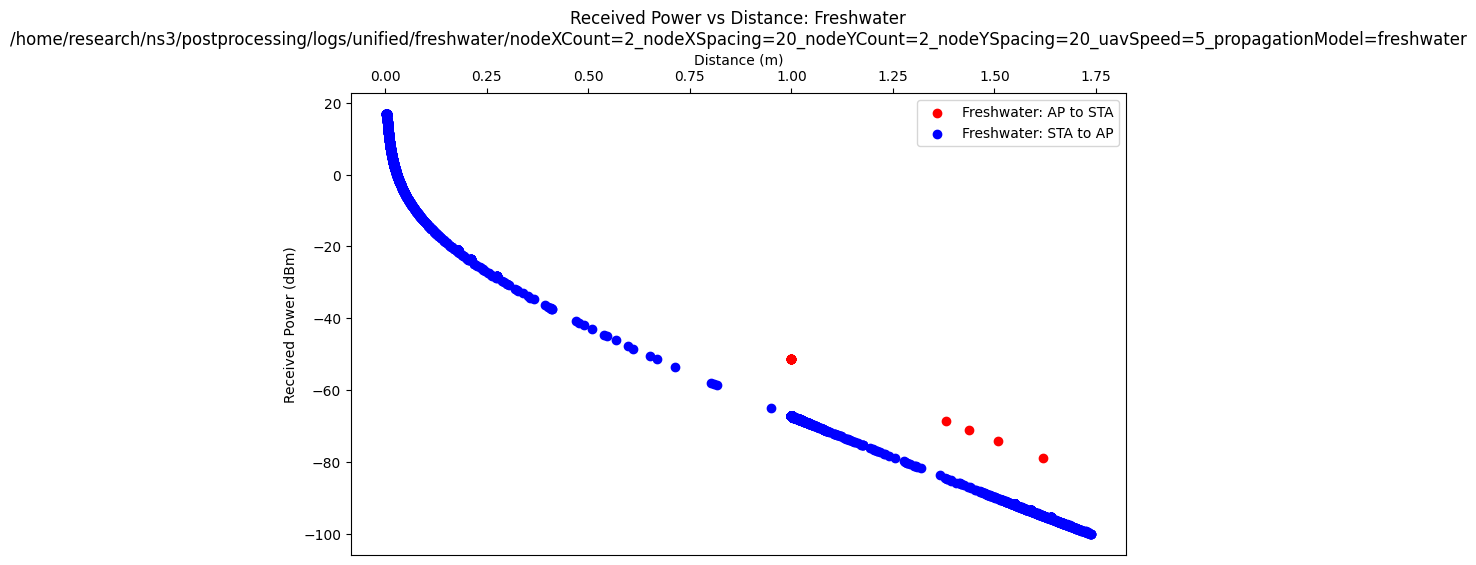

In [ ]:
fig = plt.figure(figsize=(10, 6))

# Plot freshwater scenario
# AP to STA in red
ap_to_sta_freshwater = packet_logging_stats_freshwater[
    (packet_logging_stats_freshwater['SourceNodeType'] == 'AP') & 
    (packet_logging_stats_freshwater['DestinationNodeType'] == 'STA')
]
plt.scatter(ap_to_sta_freshwater['Distance'], ap_to_sta_freshwater['LastRxSignal'], c='red', label='Freshwater: AP to STA')

# STA to AP in blue
sta_to_ap_freshwater = packet_logging_stats_freshwater[
    (packet_logging_stats_freshwater['SourceNodeType'] == 'STA') & 
    (packet_logging_stats_freshwater['DestinationNodeType'] == 'AP')
]
plt.scatter(sta_to_ap_freshwater['Distance'], sta_to_ap_freshwater['LastRxSignal'], c='blue', label='Freshwater: STA to AP')

plt.xlabel('Distance (m)')
plt.ylabel('Received Power (dBm)')
plt.title(f'Received Power vs Distance: Freshwater\n{scenario_folder_freshwater}')
plt.legend()

# Move x-axis to top
ax = plt.gca()
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

plt.show()